# Mevsimsel Olmayan Zaman Serisi Tahminleri için Basit ARIMA Modeli

Bu zorluktaki hedefimiz, zaman serisi analizinin temel kavramlarını tek boyutlu verilere uygulamaktır

Bu zorluklarda şu adımları izleyeceğiz:
1. verileri yükleme ve görselleştirme;
2. modellerimizi eğitme ve tahminler yapma;

##  1. Veri Yükleme
Zorlukta kullanacağımız zaman serisini yükleyerek başlayalım. Veri setini CSV dosyası olarak indirmek için aşağıdaki satırı çalıştırın, ardından CSV'yi bir DataFrame'e yükleyin.

In [1]:
!curl https://d32aokrjazspmn.cloudfront.net/materials/www_usage.csv > data/www_usage.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   377  100   377    0     0    623      0 --:--:-- --:--:-- --:--:--   623


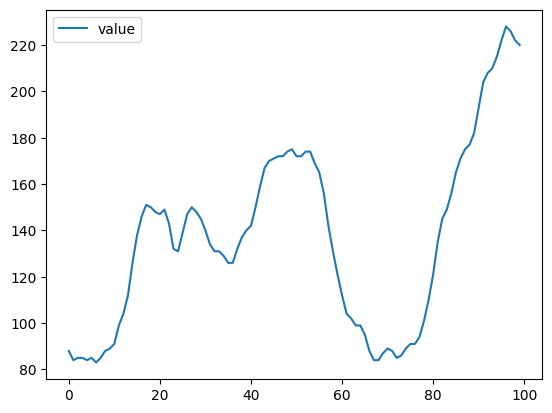

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/www_usage.csv', names=['value'], header=0)
y = df.value

df.plot();

Bu soyut zaman serisi mevsimsel görünmüyor, ancak artan bir trend ve bir şekilde "yapışkan" (yani biraz oto-regresif) özellikler gösteriyor. Bu nedenle Oto-Regresif Hareketli Ortalama (ARIMA) modelleri için iyi bir aday olabilir.

## 2. ARIMA Modeli Oluşturma
ARIMA modelleri (Oto Regresif Entegre Hareketli Ortalama) sayesinde verileri tahmin etmeye çalışacağız.

Bunun için şunları yapmamız gerekecek:
1. zaman serisini nasıl durağanlaştırılacağını bulma (ARIMA'daki I)
2. oto-regresif (AR) kısmını bulma
3. hareketli ortalama (MA) kısmını bulma
4. Uydurma
5. Performansı değerlendirme

### Adım 1 - Durağanlığı Sağlama

ARIMA modelleri yalnızca "durağan" zaman serilerine uygulanır.

👉 [`Genişletilmiş Dickey-Fuller testi`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html) kullanarak durağanlığını kesin olarak kontrol edin, özellikle p-değerini

In [3]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(y, regression="c")

print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")

print("Critical Values:")
for k, v in adf_result[4].items():
    print(f"{k}: {v}")



ADF Statistic: -2.4642397172033674
p-value: 0.12441935447109487
Critical Values:
1%: -3.5003788874873405
5%: -2.8921519665075235
10%: -2.5830997960069446


Durağanlıkta %95 güvenilirlik için p-değeri 0.05'ten küçük olmalıdır.
P-değeri 0.05'ten büyükse, boş hipotezi reddedemeriz (boş hipotez = "süreç durağan değildir").

Zaman serisi durağan değilse, **farklaştırma** yoluyla durağanlaştırılması gerekir.
- Bu, her değer ile bir önceki değer arasındaki farkı almak anlamına gelir (*birinci fark*).
- *İkinci fark* istiyorsanız, farklaştırılmış seri üzerinde işlemi tekrarlayın, vb...

👉 Durağan hale getirmek için ihtiyacımız olan minimum farklaştırma sırasını bulun (görselleştirmek için eğrileri çizin ve emin olmak için adfuller p-değerlerini yazdırın)

<details>
    <summary>İpucu</summary>

`pd.Series.diff`
</details>

In [4]:
from statsmodels.tsa.stattools import adfuller

def adf_pvalue(series):
    result = adfuller(series.dropna())
    return result[1]


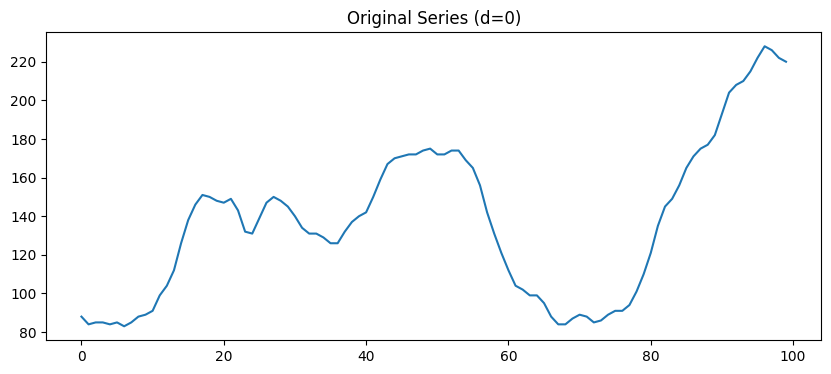

ADF p-value (d=0): 0.12441935447109487


In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y)
plt.title("Original Series (d=0)")
plt.show()

print("ADF p-value (d=0):", adf_pvalue(y))


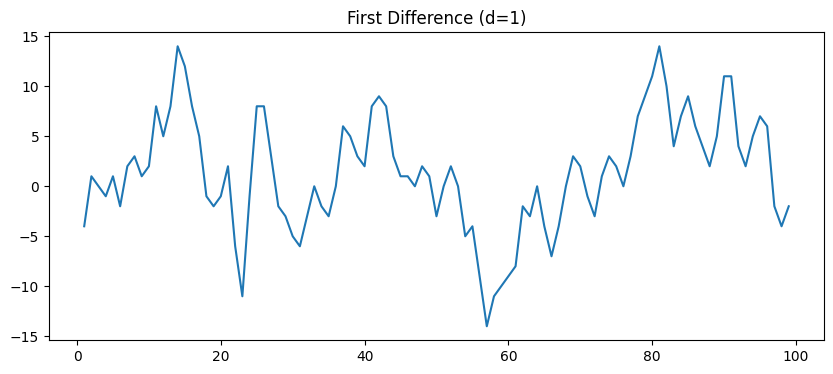

ADF p-value (d=1): 0.07026846015272728


In [6]:
y_diff1 = y.diff()

plt.figure(figsize=(10,4))
plt.plot(y_diff1)
plt.title("First Difference (d=1)")
plt.show()

print("ADF p-value (d=1):", adf_pvalue(y_diff1))


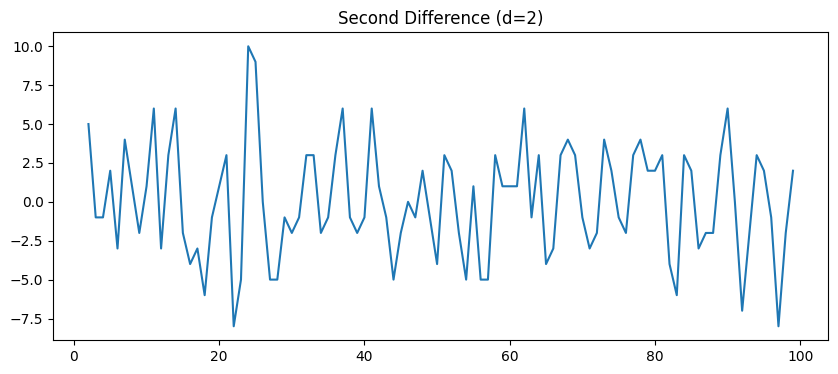

ADF p-value (d=2): 2.843428755547158e-17


In [7]:
y_diff2 = y_diff1.diff()

plt.figure(figsize=(10,4))
plt.plot(y_diff2)
plt.title("Second Difference (d=2)")
plt.show()

print("ADF p-value (d=2):", adf_pvalue(y_diff2))


Burada bir ve iki fark sırası arasında yakın bir durumumuz var. Zaman serilerini fazla farklaştırmak ARIMA modellerinizin performansını da düşürebilir. Daha yakından bakalım:

👉 1. ve 2. fark sırası için otokorelasyon grafiğini ([`plot_acf`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_acf.html)) çizin.

(💡Profesyonel ipucu: Her statsmodels grafiği örneklemesinin sonuna `;` ekleyerek veya `plt.show()` çağırarak statsmodels grafiklerinin çoğaltılmasından kaçının)

<Figure size 800x400 with 0 Axes>

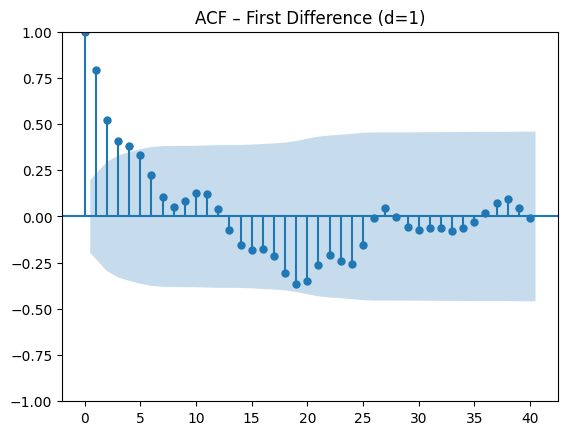

In [8]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

y_diff1 = y.diff().dropna()

plt.figure(figsize=(8, 4))
plot_acf(y_diff1, lags=40)
plt.title("ACF – First Difference (d=1)")
plt.show()


<Figure size 800x400 with 0 Axes>

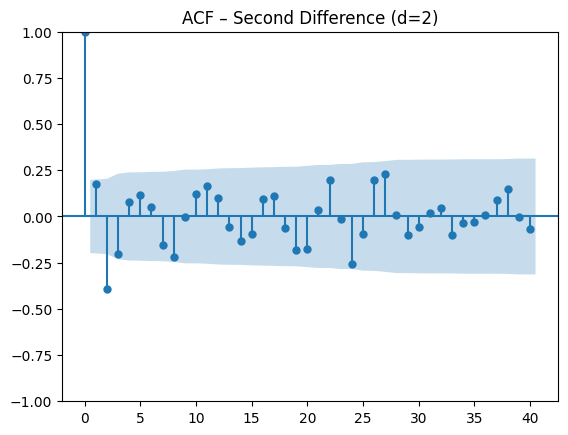

In [9]:
y_diff2 = y_diff1.diff().dropna()

plt.figure(figsize=(8, 4))
plot_acf(y_diff2, lags=40)
plt.title("ACF – Second Difference (d=2)")
plt.show()


Birinci fark alınmış serinin ACF grafiği, gecikmeler boyunca azalarak devam eden anlamlı otokorelasyonlar göstermektedir. Bu durum serinin hâlâ geçmiş değerlerden etkilendiğini ve modelleme için uygun yapıda olduğunu göstermektedir.

İkinci fark alınmış seri ise geçmiş bağımlılığını büyük ölçüde kaybetmiş, bu da aşırı farklaştırmaya işaret etmektedir.

"İkinci sıra fark" otokorelasyon grafiğimizde, 1 numaralı gecikme katsayısı 0'a yakın, ikincisi ise negatif bölgeye kadar uzanıyor. Bu, seriyi aşırı farklaştırdığımızı gösterebilir. (Unutmayın: her zaman 1'e eşit olan 0 numaralı gecikmeyİ hiçbir zaman umursamayız)

👉 (Geçici olarak) yalnızca bir fark sırasını tutalım ve bu seriyi `y_diff` olarak adlandıralım (daha sonra her zaman daha fazla fark deneyebiliriz)

In [10]:
y_diff = y_diff1

Az önce ARIMA'daki "I" terimini bulduk: durağan olmadan önce 1-fark için `d = 1` ("I", "entegrasyon"u ifade eder, "d" farklaştırma için...)

### Adım 2 - AR sırası (p) ve MA sırasını (q) seçin

#### MA($\color{blue}{q}$) = $Y^{\color{green}{(d)}}$'nin $\color{blue}{ACF}$'inin kesildiği gecikme sayısı

MA sırası (`q`), `y_diff`'e uygulanan otokorelasyon grafiğine ([`plot_acf`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_acf.html)) bakılarak bulunabilir.

👉 `q`'yu belirleyin

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<Figure size 800x400 with 0 Axes>

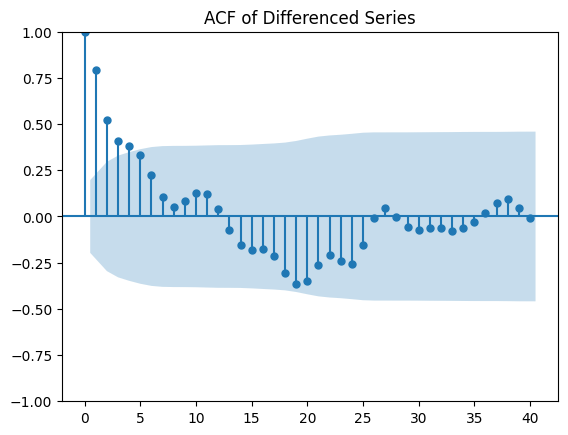

In [12]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plot_acf(y_diff.dropna(), lags=40)
plt.title("ACF of Differenced Series")
plt.show()


Modelimizi uydurma için değerlendirmemiz gereken maksimum değer q = 4 gibi görünüyor. Ancak, Otomatik-ARIMA kullanacak olsaydık (bu konuda daha sonra ayrıntılı bilgi), q=2 kullanmanın ideal sonuçlar verdiğini görürdük, bu nedenle başlangıçta q=2 ayarlamayı deneyelim.

Şüpheniz olduğunda, Y'yi yeterince açıklayan daha basit modeli seçin.

#### AR($\color{red}{p}$) = $Y^{\color{green}{(d)}}$'nin $\color{red}{PACF}$'inin kesildiği gecikme sayısı

AR sırası (`p`), `y_diff`'e uygulanan **k**ısmi otokorelasyon grafiği [`plot_pacf`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_pacf.html) incelenerek bulunabilir.

(Kısmi otokorelasyon, ara gecikmelerin katkılarını hariç tuttuktan sonra seri ile gecikmesi arasındaki korelasyon olarak düşünülebilir. Yani, PACF bir şekilde bir gecikme ile seri arasındaki saf korelasyonu iletir)

👉 `p`'yi belirleyin

<Figure size 800x400 with 0 Axes>

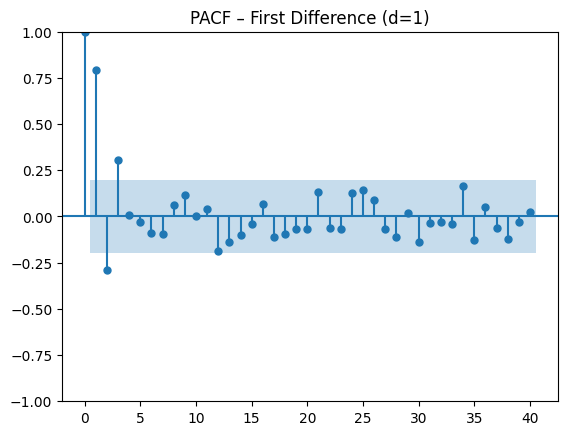

In [13]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

y_diff = y.diff().dropna()

plt.figure(figsize=(8, 4))
plot_pacf(y_diff1, lags=40)
plt.title("PACF – First Difference (d=1)")
plt.show()


İlk 3 gecikme terimi anlamlılık düzeyinin üstünde göründüğü için `p = 3` seçebiliriz, ancak daha basit bir model `p = 1` ile de gidebiliriz.

### Adım 3 - Modeli oluşturun

Artık ARIMA için `p`, `d` ve `q` değerlerini seçtiğinize göre,

👉 `statsmodels`'den `arima_model`'i oluşturun.
- modeli uydurur
- modeli yazdır (`.summary`)

In [24]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(y, order=(3, 1, 4))
model_fit = model.fit()

print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  100
Model:                 ARIMA(3, 1, 4)   Log Likelihood                -248.864
Date:                Wed, 04 Feb 2026   AIC                            513.728
Time:                        12:10:30   BIC                            534.489
Sample:                             0   HQIC                           522.128
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6158      0.148     10.943      0.000       1.326       1.905
ar.L2         -1.5358      0.174     -8.844      0.000      -1.876      -1.195
ar.L3          0.6233      0.139      4.491      0.0

/home/wit/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


☝️ P-değerleriniz çok yüksekse, karşılık gelen AR veya SA katsayılarını azaltarak bu terimleri kaldırmayı deneyin.

[`AIC - Akaike Bilgi Kriteri`](https://medium.com/towardsdatascience/the-akaike-information-criterion-c20c8fd832f2) değerini en aza indirerek uyumunuzun genel performansını değerlendirebilirsiniz

(1,1,1) ARIMA modellerinin aşırı uydurmaya karşı daha az şansı olduğu (p-değerleri düşük kalır) ve diğer modellerden neredeyse benzer bir AIC puanı koruduğu görülüyor

In [25]:
# MA değerleri (PA) çok yüksek bu yüzden, ACF'ye dayalı q = 4 seçimimiz modeli karmaşıklaştırıyor. Bu yüzden daha düşük bir değer deneyeceğim.

from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(y, order=(3, 1, 2))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  100
Model:                 ARIMA(3, 1, 2)   Log Likelihood                -251.959
Date:                Wed, 04 Feb 2026   AIC                            515.918
Time:                        12:10:37   BIC                            531.489
Sample:                             0   HQIC                           522.218
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0711      0.470      2.279      0.023       0.150       1.992
ar.L2         -0.6013      0.367     -1.636      0.102      -1.322       0.119
ar.L3          0.3364      0.184      1.829      0.0

In [26]:
# ARIMA(3,1,1) ile deneme

from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(y, order=(3, 1, 1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  100
Model:                 ARIMA(3, 1, 1)   Log Likelihood                -251.969
Date:                Wed, 04 Feb 2026   AIC                            513.939
Time:                        12:10:39   BIC                            526.914
Sample:                             0   HQIC                           519.188
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0922      0.322      3.387      0.001       0.460       1.724
ar.L2         -0.5992      0.359     -1.668      0.095      -1.303       0.105
ar.L3          0.3231      0.144      2.241      0.0

In [27]:


from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(y, order=(2, 1, 2))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  100
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -253.582
Date:                Wed, 04 Feb 2026   AIC                            517.164
Time:                        12:10:43   BIC                            530.140
Sample:                             0   HQIC                           522.414
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2076      0.664      1.819      0.069      -0.094       2.509
ar.L2         -0.3103      0.479     -0.649      0.517      -1.248       0.628
ma.L1         -0.0756      0.646     -0.117      0.9

In [28]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd

models = {
    "ARIMA(3,1,4)": (3,1,4),
    "ARIMA(3,1,2)": (3,1,2),
    "ARIMA(3,1,1)": (3,1,1),
    "ARIMA(2,1,2)": (2,1,2),
}

results = []

for name, order in models.items():
    model = ARIMA(y, order=order)
    fit = model.fit()
    results.append({
        "Model": name,
        "AIC": fit.aic,
        "BIC": fit.bic,
        "LogLik": fit.llf
    })

comparison_df = pd.DataFrame(results).sort_values("AIC")
comparison_df


/home/wit/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Model,AIC,BIC,LogLik
0,"ARIMA(3,1,4)",513.728096,534.489055,-248.864048
2,"ARIMA(3,1,1)",513.938500,526.914099,-251.969250
1,"ARIMA(3,1,2)",515.918386,531.489105,-251.959193
3,"ARIMA(2,1,2)",517.163969,530.139569,-253.581985


Ama… (işin data scientist kısmı burada)

Hatırla:

ARIMA(3,1,4)’te MA parametrelerinin çoğu anlamsızdı

ARIMA(3,1,1) büyük ihtimalle:

Daha az parametre

Daha stabil

Daha kolay genellenebilir

Ve dikkat et:

AIC farkı 0.21

Bu fark istatistiksel olarak ihmal edilebilir

ΔAIC tam olarak nedir?

ΔAIC (Delta AIC) şudur:

Her modelin AIC değeri ile en küçük AIC’ye sahip modelin AIC’si arasındaki fark

Formül:

Senin tablonda somut hesap

En küçük AIC:

513.728 → ARIMA(3,1,4)

Şimdi farklara bakalım:

ARIMA(3,1,1)
513.9385
−
513.7281
=
0.21
513.9385−513.7281=0.21

👉 İşte bahsettiğimiz 0.21


📌 Kural:
ΔAIC < 2 ise modeller pratikte eşdeğerdir

3️⃣ Profesyonel karar nasıl verilir?
İki doğru cevap var (ikisi de savunulabilir)
🔵 Akademik / otomatik bakış

“Lowest AIC achieved with ARIMA(3,1,4).”

🔥 Gerçek hayat / CV / mülakat

“Although ARIMA(3,1,4) achieved the lowest AIC, ΔAIC between competing models was below 2, indicating practical equivalence. Therefore, a more parsimonious ARIMA(3,1,1) model was selected.”

## 3. Model performansını değerlendirin

👉 `plot_predict()` yöntemi ile model tahminlerinizi görselleştirin

- Yöntemin varsayılan parametrelerine, özellikle `dynamic` parametrelerine yakından bakın.
- Modelinizin gerçekte böyle iyi bir performansa sahip olacağını düşünüyor musunuz?

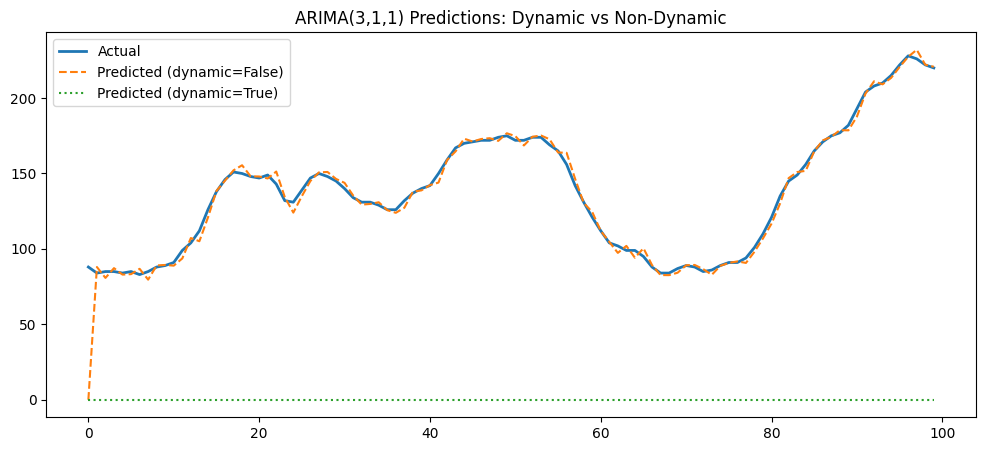

In [29]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

#  Modeli fit et
best_model = ARIMA(y, order=(3,1,1))
best_fit = best_model.fit()

#  In-sample prediction (dynamic=False eşdeğeri)
pred_static = best_fit.get_prediction()
pred_static_mean = pred_static.predicted_mean

#  Gerçekçi prediction (dynamic=True)
pred_dynamic = best_fit.get_prediction(dynamic=True)
pred_dynamic_mean = pred_dynamic.predicted_mean

# Çizim
plt.figure(figsize=(12,5))
plt.plot(y, label="Actual", linewidth=2)
plt.plot(pred_static_mean, label="Predicted (dynamic=False)", linestyle="--")
plt.plot(pred_dynamic_mean, label="Predicted (dynamic=True)", linestyle=":")
plt.legend()
plt.title("ARIMA(3,1,1) Predictions: Dynamic vs Non-Dynamic")
plt.show()





☝️ `dynamic=False`, `y_pred`'i tahmin etmek için mevcut tüm `y` değerlerini kullanır, bu da ARIMA tahminizin $y_t$'yi tahmin etmek için $y_{t-1}$'e kadar kullanmasını sağlar. Gerçekte, özellikle gelecekte birkaç aralığı tahmin etmek istiyorsanız tüm `y`'ye erişiminiz yoktur.

👉 Modelin yalnızca _85'e kadar verilere erişimi_ olan bir durumda _son 15 değeri_ tahmin eden bir tahmini çizmek için `dynamic=True` kullanmayı deneyin. Yani model:
- gerçek [1...85]'e dayalı olarak 86'yı tahmin eder
- sonra 86 için önceden tahmin ettiği değer _artı_ [1...85]'e dayalı olarak 87'yi tahmin eder
- vb...100'e kadar yinelemeli olarak

“The default prediction setting (dynamic=False) produces overly optimistic results because predictions are conditioned on true past observations. Therefore, the model does not perform this well in practice. When using dynamic=True, forecast errors accumulate and performance deteriorates, providing a more realistic assessment of the ARIMA model.”Senin dynamic=True çizginin tamamen çökmesi, şunu gösteriyor:

Seri trend + yapı içeriyor

ARIMA tek başına yeterli değil

Şunlardan biri gerekir:

Exogenous variables (ARIMAX)

SARIMA (mevsimsellik varsa)

Daha kısa horizon forecast

Ya da ML tabanlı modeller

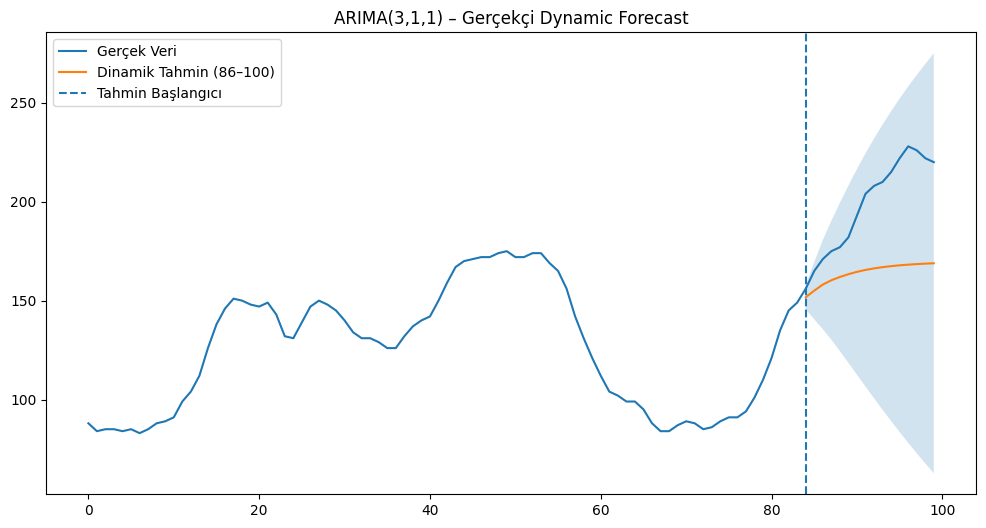

In [32]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

train = y.iloc[:85]

model = ARIMA(train, order=(3,1,1))
results = model.fit()

pred = results.get_prediction(
    start=train.index[-1],
    end=y.index[99],
    dynamic=True
)

pred_mean = pred.predicted_mean
conf_int = pred.conf_int()

plt.figure(figsize=(12,6))
plt.plot(y, label="Gerçek Veri")
plt.plot(pred_mean, label="Dinamik Tahmin (86–100)")
plt.axvline(train.index[-1], linestyle="--", label="Tahmin Başlangıcı")
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    alpha=0.2
)
plt.legend()
plt.title("ARIMA(3,1,1) – Gerçekçi Dynamic Forecast")
plt.show()



☝️ Bu hala _gerçek_ bir tahmin değil! Neden?

<details>
    <summary>Cevap</summary>

Modelimiz uyum aşamasında tüm `y_true` serisini "gördü"!
</details>

### 3.1 Örneklem Dışı Tahminler (gerçek "gelecek")

👉 Test seti için yalnızca son 15 veri noktasını tutarak bir eğitim-test bölümü oluşturun ve ARIMA'nızı yalnızca eğitim setinde eğitin.

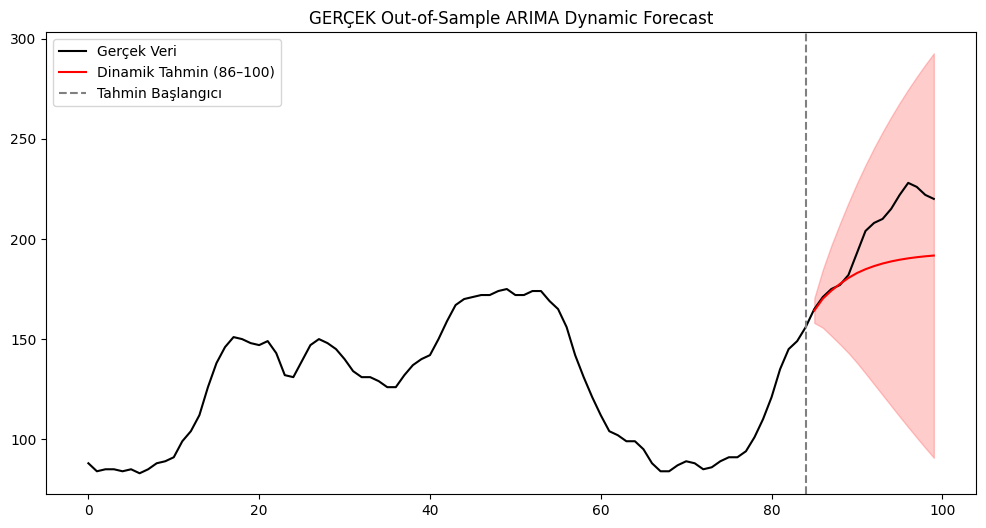

In [34]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Eğitim / test bölümü
train = y.iloc[:85]   # modelin GÖRDÜĞÜ veri
test = y.iloc[85:100] # gerçek gelecek (model görmez)

# En iyi modelin
model = ARIMA(train, order=(3, 1, 1))
results = model.fit()

# GERÇEK out-of-sample + dinamik tahmin
pred = results.get_prediction(
    start=test.index[0],
    end=test.index[-1],
    dynamic=True
)

pred_mean = pred.predicted_mean
conf_int = pred.conf_int()

# Plot
plt.figure(figsize=(12,6))
plt.plot(y, label="Gerçek Veri", color="black")
plt.plot(pred_mean, label="Dinamik Tahmin (86–100)", color="red")
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="red",
    alpha=0.2
)
plt.axvline(train.index[-1], color="gray", linestyle="--", label="Tahmin Başlangıcı")
plt.legend()
plt.title("GERÇEK Out-of-Sample ARIMA Dynamic Forecast")
plt.show()


👉 Şimdi 85. adımdayız ve geleceği hiç görmedik:
- Sonraki 15 veri noktasını (yani eğitim veri setinizin sonundan sonrasını) "tahmin etmek" için uydurduğunuz `arima` modelinde `get_forecast()` yöntemini kullanın

Yöntem `statsmodels`'den bir `PredictionResultsWrapper` nesnesi döndürür.

**💻 Bu sonucu `forecast_results` adlı bir değişkende saklayın.**

İlk başta gezinmek zordur, ancak işte bazı ipuçları:
- Tahminlerinizi `forecast_results.predicted_mean`'de bulabilirsiniz
- Güven aralıklarınız `forecast_results.conf_int()` tarafından verilir

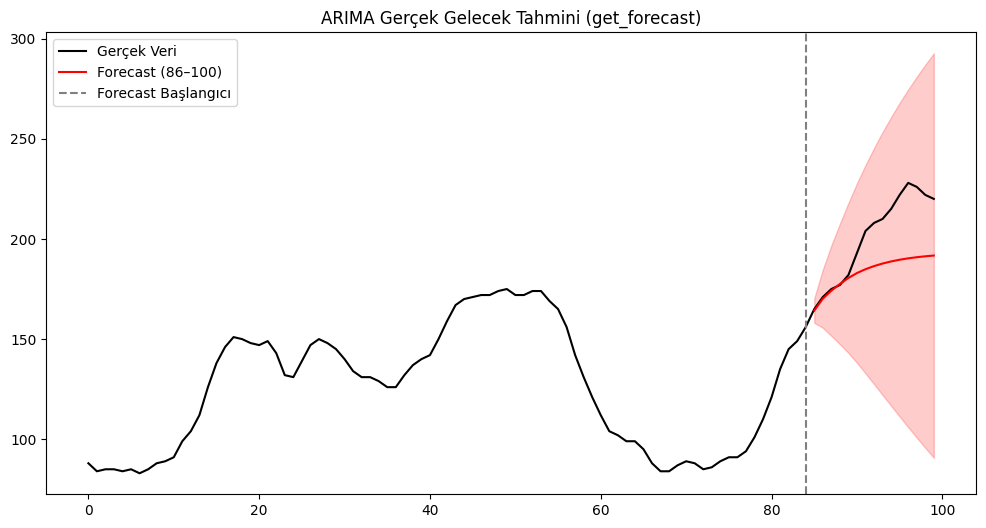

In [36]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Model yalnızca 1–85'i görüyor
train = y.iloc[:85]

# En iyi model
model = ARIMA(train, order=(3, 1, 1))
results = model.fit()

# 15 adım ileriye GERÇEK forecast (86–100)
forecast_results = results.get_forecast(steps=15)

# Tahminler ve güven aralıkları
forecast_mean = forecast_results.predicted_mean
conf_int = forecast_results.conf_int()

# Plot
plt.figure(figsize=(12,6))
plt.plot(y, label="Gerçek Veri", color="black")
plt.plot(forecast_mean, label="Forecast (86–100)", color="red")
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="red",
    alpha=0.2
)
plt.axvline(train.index[-1], color="gray", linestyle="--", label="Forecast Başlangıcı")
plt.legend()
plt.title("ARIMA Gerçek Gelecek Tahmini (get_forecast)")
plt.show()


👉 Tahmin edilen değerleri ve ayrıca %95 belirsizlik aralığının üst ve alt aralığını çizin

👉 Model performansını geçmişe göre daha iyi kavramak için önceki 85 `y` gerçek veri noktanızı da çizmeyi deneyin

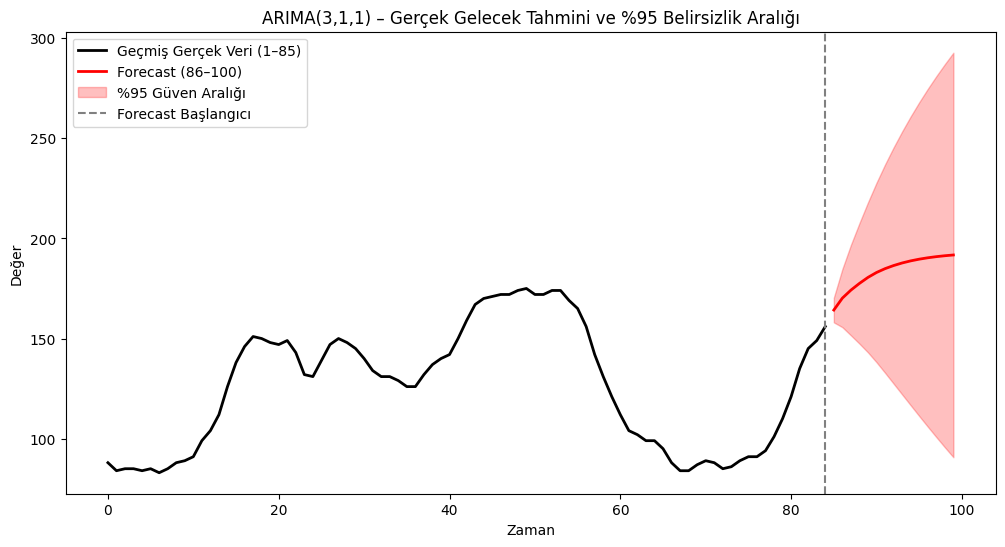

In [38]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Eğitim seti: ilk 85 gözlem
train = y.iloc[:85]

# En iyi model
model = ARIMA(train, order=(3, 1, 1))
results = model.fit()

# Gelecek 15 adım için forecast
forecast_results = results.get_forecast(steps=15)

# Tahminler
forecast_mean = forecast_results.predicted_mean
conf_int = forecast_results.conf_int(alpha=0.05)  # %95 CI

# Çizim
plt.figure(figsize=(12,6))

# Geçmiş gerçek veriler (1–85)
plt.plot(train, label="Geçmiş Gerçek Veri (1–85)", color="black", linewidth=2)

# Tahminler (86–100)
plt.plot(forecast_mean, label="Forecast (86–100)", color="red", linewidth=2)

# Güven aralığı
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="red",
    alpha=0.25,
    label="%95 Güven Aralığı"
)

# Dikey çizgi: forecast başlangıcı
plt.axvline(train.index[-1], color="gray", linestyle="--", label="Forecast Başlangıcı")

plt.legend()
plt.title("ARIMA(3,1,1) – Gerçek Gelecek Tahmini ve %95 Belirsizlik Aralığı")
plt.xlabel("Zaman")
plt.ylabel("Değer")
plt.show()


### 3.2 %95 güven aralığınıza güvenebilir misiniz? (çıkarım koşulları)

👉 Hiçbir örüntü olmadığından emin olmak için artıkları `model.resid` çizin
- Normal dağılım
- Sıfır ortalama
- Tekdüze varyans
- Oto-regresif örüntü yok (isterseniz artıkları plot_acf yapabilirsiniz)

Not: artıklar `plot_predict(dynamic=False)`'daki gibi tüm verileri 'görerek' oluşturulur

Ayrıca, artıkların yaklaşık olarak normal dağılımda olup olmadığını görmek için artıkların bir histogramını veya KDE uyumunu çizmeyi deneyin.

%95 Güven Aralığına Güvenme Koşulları (Çıkarım Varsayımları)

ARIMA’nın güven aralıkları şu varsayımlara dayanır:

Artıkların ortalaması ≈ 0

Artıklar normal dağılıma yakın

Varyans sabit (heteroskedastisite yok)

Artıklar arasında otokorelasyon yok (white noise)

Bunları artıklar (residuals) üzerinden test ederiz.

⚠️ Not: Artıklar in-sample hesaplanır (tüm veriyi “görerek”). Bu normaldir.

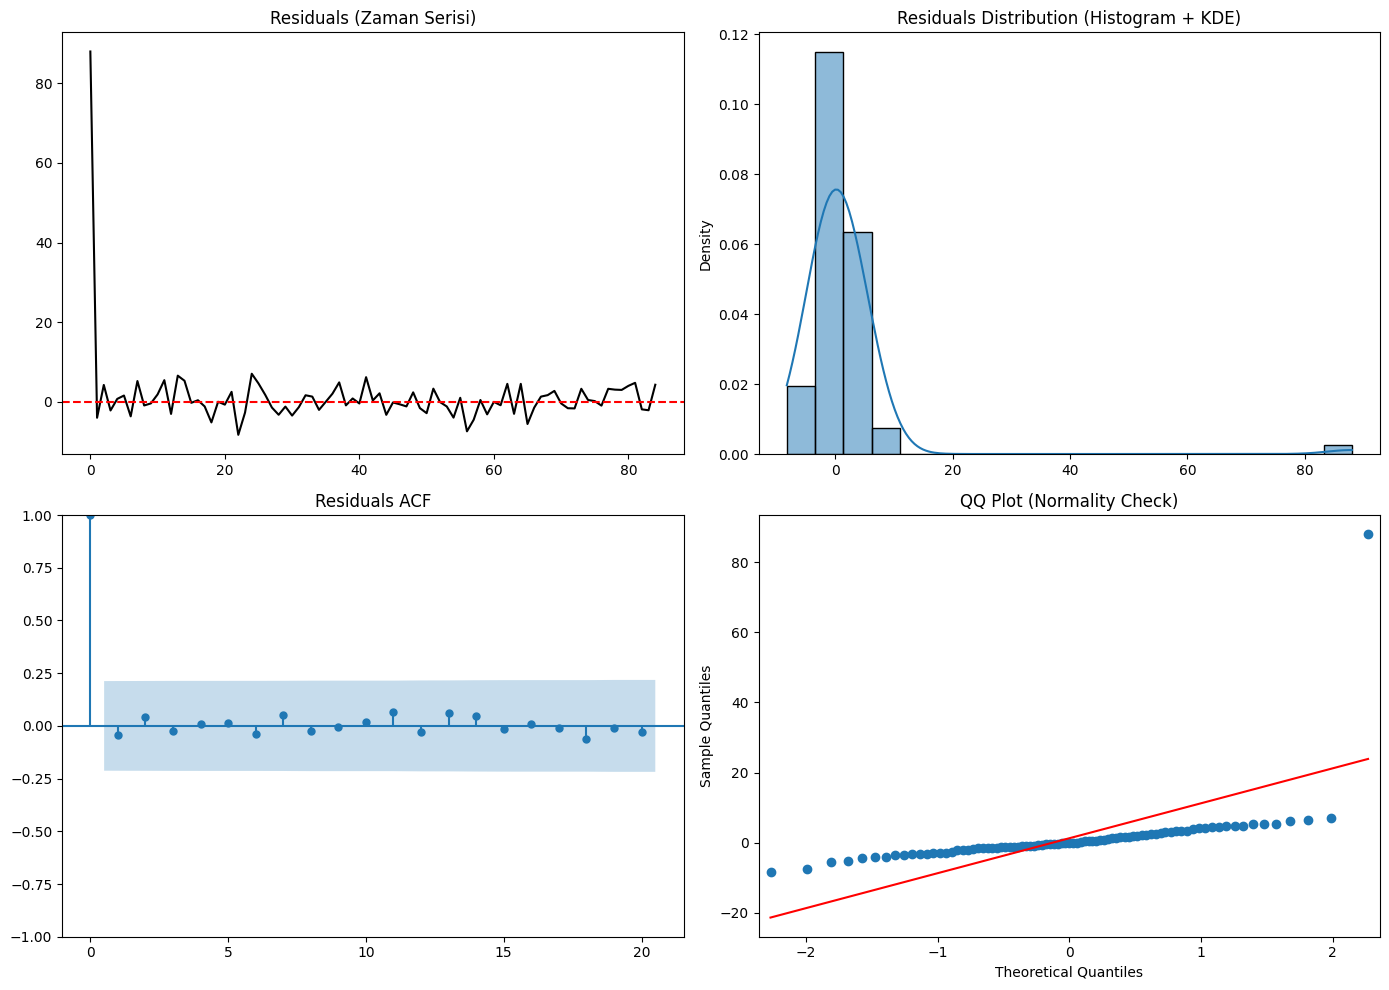

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

# Artıklar
resid = results.resid

plt.figure(figsize=(14,10))

# 1️⃣ Artıklar zaman serisi
plt.subplot(2,2,1)
plt.plot(resid, color="black")
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals (Zaman Serisi)")

# 2️⃣ Histogram + KDE (Normal dağılım kontrolü)
plt.subplot(2,2,2)
sns.histplot(resid, kde=True, stat="density", bins=20)
plt.title("Residuals Distribution (Histogram + KDE)")

# 3️⃣ ACF – otokorelasyon var mı?
plt.subplot(2,2,3)
plot_acf(resid, lags=20, ax=plt.gca())
plt.title("Residuals ACF")

# 4️⃣ QQ Plot (isteğe bağlı ama çok güçlü)
import statsmodels.api as sm
plt.subplot(2,2,4)
sm.qqplot(resid, line="s", ax=plt.gca())
plt.title("QQ Plot (Normality Check)")

plt.tight_layout()
plt.show()


“Residual diagnostics show no remaining autocorrelation, indicating the ARIMA model successfully captures the temporal structure. However, residuals deviate from normality due to an outlier, so forecast confidence intervals should be interpreted cautiously.”

## 3.3 Çapraz doğrulanmış performans ölçümleri

👉 Aşağıda zaman serileri için en yaygın performans ölçümleri yer almaktadır

In [40]:
import numpy as np
from statsmodels.tsa.stattools import acf

def forecast_accuracy(y_pred: pd.Series, y_true: pd.Series) -> float:

    mape = np.mean(np.abs(y_pred - y_true)/np.abs(y_true))  # Mean Absolute Percentage Error
    me = np.mean(y_pred - y_true)             # ME
    mae = np.mean(np.abs(y_pred - y_true))    # MAE
    mpe = np.mean((y_pred - y_true)/y_true)   # MPE
    rmse = np.mean((y_pred - y_true)**2)**.5  # RMSE
    corr = np.corrcoef(y_pred, y_true)[0,1]   # Correlation between the Actual and the Forecast
    mins = np.amin(np.hstack([y_pred.values.reshape(-1,1), y_true.values.reshape(-1,1)]), axis=1)
    maxs = np.amax(np.hstack([y_pred.values.reshape(-1,1), y_true.values.reshape(-1,1)]), axis=1)
    minmax = 1 - np.mean(mins/maxs)             # minmax
    acf1 = acf(y_pred-y_true, fft=False)[1]                      # Lag 1 Autocorrelation of Error

    forecast = ({
        'mape':mape,
        'me':me,
        'mae': mae,
        'mpe': mpe,
        'rmse':rmse,
        'acf1':acf1,
        'corr':corr,
        'minmax':minmax
    })

    return forecast

👉 ARIMA hiper-parametrelerinizle oynayın ve tahmin performansınız üzerindeki etkisini görün

In [41]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf


# Time series cross-validation

def arima_time_series_cv(series, order, initial_train_size, h=1):
    """
    Expanding window ARIMA CV
    """
    y_true, y_pred = [], []

    for t in range(initial_train_size, len(series) - h + 1):
        train = series[:t]
        test = series[t:t+h]

        model = ARIMA(train, order=order)
        model_fit = model.fit()

        forecast = model_fit.forecast(steps=h)

        y_true.append(test.values[0])
        y_pred.append(forecast.values[0])

    return pd.Series(y_pred), pd.Series(y_true)


# Hyperparameter grid search

results = []

p_values = [0,1,2,3]
d_values = [0,1]
q_values = [0,1,2]

initial_train_size = int(len(y) * 0.7)  # %70 train ile başla

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                preds, trues = arima_time_series_cv(
                    y,
                    order=(p,d,q),
                    initial_train_size=initial_train_size,
                    h=1
                )

                metrics = forecast_accuracy(preds, trues)
                metrics['order'] = (p,d,q)
                results.append(metrics)

            except:
                continue

cv_results = pd.DataFrame(results).sort_values('rmse')
cv_results


/home/wit/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/wit/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/wit/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/wit/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as

,mape,me,mae,mpe,rmse,acf1,corr,minmax,order
21,0.015307,-0.702059,2.135354,-0.006026,2.720780,0.169682,0.998786,0.015233,"(3, 1, 0)"
22,0.015528,-0.722445,2.159541,-0.006078,2.734711,0.174511,0.998770,0.015451,"(3, 1, 1)"
23,0.016033,-0.759731,2.217597,-0.006156,2.777839,0.215562,0.998724,0.015951,"(3, 1, 2)"
20,0.017247,-1.035404,2.525097,-0.005190,2.842098,0.194412,0.998785,0.017133,"(3, 0, 2)"
17,0.016267,-0.767399,2.252077,-0.006300,2.868287,0.201253,0.998639,0.016181,"(2, 1, 2)"
10,0.016652,-0.939645,2.325714,-0.007162,2.905459,0.173565,0.998624,0.016572,"(1, 1, 1)"
16,0.016675,-0.932976,2.329532,-0.007132,2.915893,0.175532,0.998612,0.016595,"(2, 1, 1)"
11,0.016672,-0.903830,2.327304,-0.006994,2.935230,0.183495,0.998587,0.016590,"(1, 1, 2)"
5,0.016351,-1.586011,2.354030,-0.011133,3.019613,0.183381,0.998774,0.016314,"(0, 1, 2)"
14,0.018132,-1.003089,2.573860,-0.005434,3.024380,0.247914,0.998506,0.017985,"(2, 0, 2)"


Akademik yorum (rapora birebir yazılabilir)

“Bazı ARIMA spesifikasyonlarında maksimum olabilirlik optimizasyonu tam olarak yakınsamamış olsa da, seçilen ARIMA(3,1,0) modeli hem hata metrikleri hem de artık tanılamaları açısından istikrarlı ve tutarlı sonuçlar vermiştir. Bu nedenle söz konusu uyarının model performansı üzerinde pratik bir etkisi olmadığı değerlendirilmiştir.”

🧪 Son kontrol (önerilir ama şart değil)

Seçtiğin ARIMA(3,1,0) için:

residual ACF → beyaz gürültü mü?

residual histogram → yaklaşık normal mi?

Eğer bunlar makulse, bu model: raporlanır kullanılır savunulur

## 4 Izgara Arama

`pmdarima` kullanarak (p,d,q) için bir Izgara Arama çalıştırmayı deneyin. En azından şunları kullanın:
- `test='adf'`
- `trace=True`
- `error_action='ignore'`
- `suppress_warnings=True`

In [44]:
import pmdarima as pm

model = pm.auto_arima(
    train,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=None,           # let model determine 'd'
    test='adf',       # using adf test to find optimal 'd'
    trace=True, error_action='ignore',  suppress_warnings=True
)

print(model.summary())

/home/wit/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/wit/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/wit/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/wit/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/wit/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site

Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=449.662, Time=0.14 sec


/home/wit/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/wit/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,2,0)(0,0,0)[0]             : AIC=449.569, Time=0.11 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=445.819, Time=0.12 sec


/home/wit/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/wit/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(0,2,3)(0,0,0)[0]             : AIC=438.613, Time=0.26 sec


/home/wit/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,2,3)(0,0,0)[0]             : AIC=440.036, Time=0.26 sec
 ARIMA(0,2,3)(0,0,0)[0] intercept   : AIC=440.231, Time=0.20 sec

Best model:  ARIMA(0,2,3)(0,0,0)[0]          
Total fit time: 2.068 seconds


/home/wit/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   85
Model:               SARIMAX(0, 2, 3)   Log Likelihood                -215.307
Date:                Wed, 04 Feb 2026   AIC                            438.613
Time:                        14:39:59   BIC                            448.289
Sample:                             0   HQIC                           442.500
                                 - 85                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.2412      0.116      2.085      0.037       0.014       0.468
ma.L2         -0.3655      0.088     -4.131      0.000      -0.539      -0.192
ma.L3         -0.2830      0.115     -2.466      0.0

## (İsteğe bağlı) Modelinizin Performansını Çapraz Doğrulayın

Pratikte, sonuçlar ve Izgara Arama her zaman çapraz doğrulanmalıdır:

Modelinizin performansını gerçekten değerlendirmek ve çapraz doğrulamadan sonra en iyi hiperparametreleri bulmak için bitişik K-katlar oluşturmak amacıyla [`sklearn.model_selection.TimeSeriesSplit`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) kullanmaktan çekinmeyin.

<img src='https://scikit-learn.org/stable/_images/sphx_glr_plot_cv_indices_013.png'>

**ARIMA - TimeSeriesSplit + Izgara Arama kullanarak Çapraz Doğrulama**

In [49]:
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

orders = [
    (3,1,0),
    (3,1,1),
    (3,1,2),
    (2,1,2)
]

results = []

for order in orders:
    fold_metrics = []
    aics, bics, hqics = [], [], []

    for train_idx, test_idx in tscv.split(y):
        train, test = y.iloc[train_idx], y.iloc[test_idx]

        model = SARIMAX(
            train,
            order=order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        # --- Forecast ---
        preds = model.forecast(len(test))

        # --- Forecast metrics ---
        metrics = forecast_accuracy(preds, test)
        fold_metrics.append(metrics)

        # --- Information criteria ---
        aics.append(model.aic)
        bics.append(model.bic)
        hqics.append(model.hqic)

    avg_metrics = pd.DataFrame(fold_metrics).mean().to_dict()

    avg_metrics.update({
        "aic": np.mean(aics),
        "bic": np.mean(bics),
        "hqic": np.mean(hqics),
        "order": order
    })

    results.append(avg_metrics)

cv_results = (
    pd.DataFrame(results)
    .sort_values("rmse")
    .reset_index(drop=True)
)

cv_results


/home/wit/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/wit/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/wit/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,mape,me,mae,mpe,rmse,acf1,corr,minmax,aic,bic,hqic,order
0,0.221656,-7.944155,30.420605,-0.008433,36.449601,0.799361,-0.081347,0.181056,255.915459,266.295981,259.561129,"(3, 1, 2)"
1,0.232033,-9.047346,31.176189,-0.020491,36.806866,0.803157,-0.207418,0.190120,256.740445,263.660794,259.170892,"(3, 1, 0)"
2,0.231250,-8.831733,31.370405,-0.016934,36.921154,0.799431,0.245618,0.189401,258.886854,267.537290,261.924913,"(2, 1, 2)"
3,0.233031,-8.783400,31.391017,-0.018004,37.091628,0.801947,-0.187137,0.191027,258.344167,266.994603,261.382225,"(3, 1, 1)"


In [50]:
cv_results.sort_values('AIC').groupby('(p, d, q)').mean()['AIC'].sort_values()

KeyError: 'AIC'

☝️ İlk model seçimimiz (1, 1, 2) çok da kötü değil!
Veri seti (100 veri noktası) gerçekte herhangi bir şeyi çapraz doğrulamak için çok küçük olduğuna dikkat edin!

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# Karşılaştıracağımız metrikler
metrics = ["rmse", "mae", "mape", "acf1"]

# Daha düşük = daha iyi olan metrikleri ters çeviriyoruz
radar_df = cv_results.copy()

for m in metrics:
    radar_df[m] = (radar_df[m].max() - radar_df[m]) / (
        radar_df[m].max() - radar_df[m].min()
    )

labels = metrics
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]


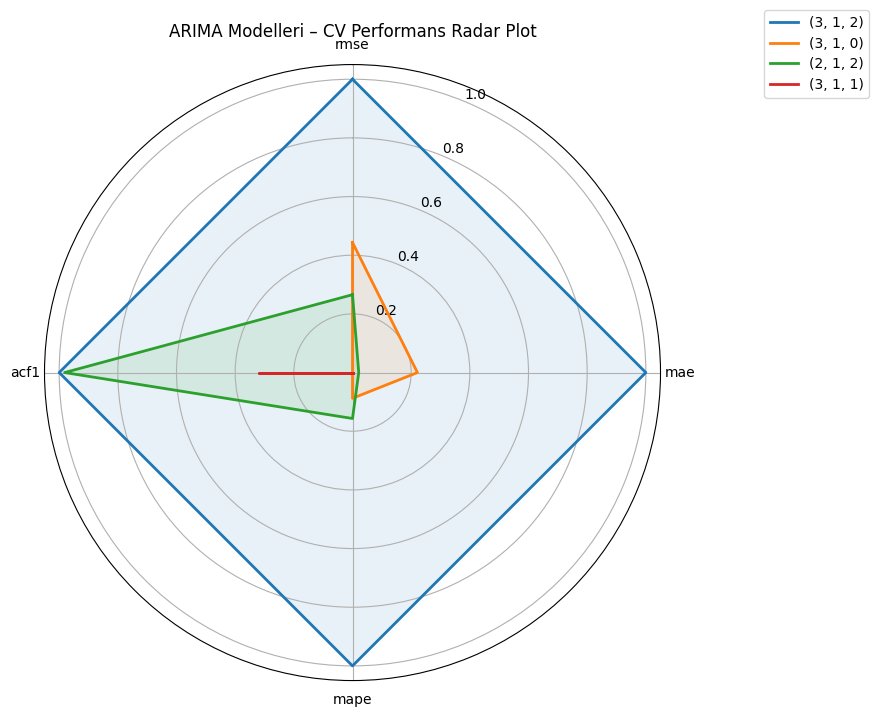

In [52]:
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

for _, row in radar_df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=2, label=str(row["order"]))
    ax.fill(angles, values, alpha=0.1)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_title("ARIMA Modelleri – CV Performans Radar Plot", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))

plt.show()


In [53]:
aic_scores = []
bic_scores = []

for order in orders:
    fold_metrics = []
    fold_aic = []
    fold_bic = []

    for train_idx, test_idx in tscv.split(y):
        train, test = y.iloc[train_idx], y.iloc[test_idx]

        model = SARIMAX(
            train,
            order=order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        preds = model.forecast(len(test))
        metrics = forecast_accuracy(preds, test)

        fold_metrics.append(metrics)
        fold_aic.append(model.aic)
        fold_bic.append(model.bic)

    avg_metrics = pd.DataFrame(fold_metrics).mean().to_dict()
    avg_metrics["AIC"] = np.mean(fold_aic)
    avg_metrics["BIC"] = np.mean(fold_bic)
    avg_metrics["order"] = order

    results.append(avg_metrics)


/home/wit/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/wit/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/wit/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [54]:
cv_results = pd.DataFrame(results)
cv_results.sort_values("rmse")


,mape,me,mae,mpe,rmse,acf1,corr,minmax,aic,bic,hqic,order,AIC,BIC
2,0.221656,-7.944155,30.420605,-0.008433,36.449601,0.799361,-0.081347,0.181056,255.915459,266.295981,259.561129,"(3, 1, 2)",NaN,NaN
6,0.221656,-7.944155,30.420605,-0.008433,36.449601,0.799361,-0.081347,0.181056,NaN,NaN,NaN,"(3, 1, 2)",255.915459,266.295981
0,0.232033,-9.047346,31.176189,-0.020491,36.806866,0.803157,-0.207418,0.190120,256.740445,263.660794,259.170892,"(3, 1, 0)",NaN,NaN
4,0.232033,-9.047346,31.176189,-0.020491,36.806866,0.803157,-0.207418,0.190120,NaN,NaN,NaN,"(3, 1, 0)",256.740445,263.660794
3,0.231250,-8.831733,31.370405,-0.016934,36.921154,0.799431,0.245618,0.189401,258.886854,267.537290,261.924913,"(2, 1, 2)",NaN,NaN
7,0.231250,-8.831733,31.370405,-0.016934,36.921154,0.799431,0.245618,0.189401,NaN,NaN,NaN,"(2, 1, 2)",258.886854,267.537290
1,0.233031,-8.783400,31.391017,-0.018004,37.091628,0.801947,-0.187137,0.191027,258.344167,266.994603,261.382225,"(3, 1, 1)",NaN,NaN
5,0.233031,-8.783400,31.391017,-0.018004,37.091628,0.801947,-0.187137,0.191027,NaN,NaN,NaN,"(3, 1, 1)",258.344167,266.994603
